<a href="https://colab.research.google.com/github/bheemeshpujari63/toxic-comment-classification/blob/main/toxic_comment_classification.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Toxic Comment Classification

## 1. Problem Definition

## 2. Dataset Understanding

## 3. Exploratory Data Analysis

## 4. Text Preprocessing

## 5. Train-Validation Split

## 6. Text Representation

## 7. Baseline Model

## 8. Model Evaluation

## 9. Error Analysis

## 10. Model Improvement

## 11. Deep Learning / Transformer Model

## 12. Model Comparison

## 13. Final Model

## 14. Conclusion

# 1. Problem Definition

## Objective

Build a machine learning system that takes an online comment as input
and predicts whether it contains one or more forms of toxic behavior.

## Toxicity Categories

The dataset contains six toxicity labels:

- toxic
- severe_toxic
- obscene
- threat
- insult
- identity_hate

## Problem Type

This is a multi-label text classification problem.

A single comment can belong to multiple toxicity categories simultaneously.

## Goal

Build an NLP pipeline that:

1. Understands and explores the dataset
2. Preprocesses the text
3. Converts text into numerical features
4. Trains machine learning models
5. Evaluates their performance
6. Performs error analysis
7. Improves the model
8. Compares classical ML with a more advanced NLP approach

In [2]:
import pandas as pd

In [3]:
train_df = pd.read_csv("/content/train.csv")
train_df.head()

,id,comment_text,toxic,severe_toxic,obscene,threat,insult,identity_hate
0,0000997932d777bf,Explanation\nWhy the edits made under my usern...,0,0,0,0,0,0
1,000103f0d9cfb60f,D'aww! He matches this background colour I'm s...,0,0,0,0,0,0
2,000113f07ec002fd,"Hey man, I'm really not trying to edit war. It...",0,0,0,0,0,0
3,0001b41b1c6bb37e,"""\nMore\nI can't make any real suggestions on ...",0,0,0,0,0,0
4,0001d958c54c6e35,"You, sir, are my hero. Any chance you remember...",0,0,0,0,0,0


In [4]:
train_df.shape

(159571, 8)

In [5]:
train_df.columns

Index(['id', 'comment_text', 'toxic', 'severe_toxic', 'obscene', 'threat',
       'insult', 'identity_hate'],
      dtype='object')

In [6]:
train_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 159571 entries, 0 to 159570
Data columns (total 8 columns):
 #   Column         Non-Null Count   Dtype 
---  ------         --------------   ----- 
 0   id             159571 non-null  object
 1   comment_text   159571 non-null  object
 2   toxic          159571 non-null  int64 
 3   severe_toxic   159571 non-null  int64 
 4   obscene        159571 non-null  int64 
 5   threat         159571 non-null  int64 
 6   insult         159571 non-null  int64 
 7   identity_hate  159571 non-null  int64 
dtypes: int64(6), object(2)
memory usage: 9.7+ MB


In [7]:
train_df.isnull().sum()

,0
id,0
comment_text,0
toxic,0
severe_toxic,0
obscene,0
threat,0
insult,0
identity_hate,0


## Label Distribution

Before training a model, we need to understand how frequently each toxicity label occurs.

This is important because highly imbalanced labels can make accuracy misleading and may require special evaluation or modeling strategies.

In [9]:
label_columns = [
    "toxic",
    "severe_toxic",
    "obscene",
    "threat",
    "insult",
    "identity_hate"
]

train_df[label_columns].sum()

,0
toxic,15294
severe_toxic,1595
obscene,8449
threat,478
insult,7877
identity_hate,1405


In [10]:
train_df[label_columns].mean() * 100

,0
toxic,9.584448
severe_toxic,0.999555
obscene,5.294822
threat,0.299553
insult,4.936361
identity_hate,0.880486


## Multi-Label Structure

A comment can have multiple toxicity labels at the same time.

We will calculate how many positive labels are assigned to each comment to understand the multi-label nature of the dataset.

In [11]:
train_df["num_labels"] = train_df[label_columns].sum(axis=1)

train_df["num_labels"].value_counts().sort_index()

,count
num_labels,
0,143346
1,6360
2,3480
3,4209
4,1760
5,385
6,31


In [12]:
train_df[label_columns].corr()

,toxic,severe_toxic,obscene,threat,insult,identity_hate
toxic,1.000000,0.308619,0.676515,0.157058,0.647518,0.266009
severe_toxic,0.308619,1.000000,0.403014,0.123601,0.375807,0.201600
obscene,0.676515,0.403014,1.000000,0.141179,0.741272,0.286867
threat,0.157058,0.123601,0.141179,1.000000,0.150022,0.115128
insult,0.647518,0.375807,0.741272,0.150022,1.000000,0.337736
identity_hate,0.266009,0.201600,0.286867,0.115128,0.337736,1.000000


In [13]:
# Number of completely non-toxic comments
clean_comments = (train_df[label_columns].sum(axis=1) == 0).sum()

# Number of comments with at least one toxic label
toxic_comments = (train_df[label_columns].sum(axis=1) > 0).sum()

print("Clean comments:", clean_comments)
print("Comments with at least one toxic label:", toxic_comments)

Clean comments: 143346
Comments with at least one toxic label: 16225


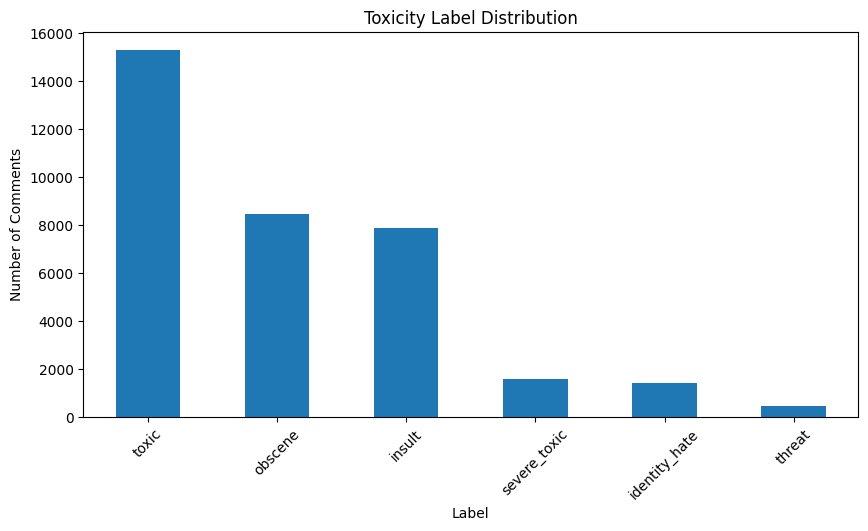

In [14]:
import matplotlib.pyplot as plt

label_counts = train_df[label_columns].sum().sort_values(ascending=False)

plt.figure(figsize=(10, 5))
label_counts.plot(kind="bar")
plt.title("Toxicity Label Distribution")
plt.ylabel("Number of Comments")
plt.xlabel("Label")
plt.xticks(rotation=45)
plt.show()

## 5. Train-Validation Split

We split the labeled data into training and validation sets.

The training set is used to learn model parameters, while the validation set is used to estimate performance on unseen examples during development.

The validation set must remain separate from training data to reduce the risk of overestimating model performance.

In [15]:
from sklearn.model_selection import train_test_split

X = train_df["comment_text"]
y = train_df[label_columns]

X_train, X_val, y_train, y_val = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=42,
    stratify=train_df["toxic"]
)

print("Training samples:", len(X_train))
print("Validation samples:", len(X_val))

Training samples: 127656
Validation samples: 31915


In [16]:
import re

def clean_text(text):
    text = str(text)

    # Replace URLs with a common token
    text = re.sub(r"http\S+|www\S+", " URL ", text)

    # Remove HTML tags
    text = re.sub(r"<.*?>", " ", text)

    # Normalize whitespace
    text = re.sub(r"\s+", " ", text).strip()

    return text

In [17]:
X_train_clean = X_train.apply(clean_text)
X_val_clean = X_val.apply(clean_text)

print("Original:")
print(X_train.iloc[0])

print("\nCleaned:")
print(X_train_clean.iloc[0])

Original:
And more unfounded personal attacks by  here at Beeblebroxe's talk page. It just gets better and better. I suppose I am to blame for that conduct as well. Its somehow my fault I guess.

Cleaned:
And more unfounded personal attacks by here at Beeblebroxe's talk page. It just gets better and better. I suppose I am to blame for that conduct as well. Its somehow my fault I guess.


## 6. Text Representation — TF-IDF

Machine learning algorithms cannot directly operate on raw sentences.

We therefore transform text into numerical features using TF-IDF (Term Frequency-Inverse Document Frequency).

TF-IDF gives higher importance to terms that are frequent in a particular document but relatively uncommon across the entire corpus.

In [18]:
from sklearn.feature_extraction.text import TfidfVectorizer

tfidf = TfidfVectorizer(
    lowercase=True,
    strip_accents="unicode",
    ngram_range=(1, 2),
    min_df=2,
    max_features=200000,
    sublinear_tf=True
)

X_train_tfidf = tfidf.fit_transform(X_train_clean)
X_val_tfidf = tfidf.transform(X_val_clean)

print("Training matrix shape:", X_train_tfidf.shape)
print("Validation matrix shape:", X_val_tfidf.shape)

Training matrix shape: (127656, 200000)
Validation matrix shape: (31915, 200000)


## 7. Baseline Model — One-vs-Rest Logistic Regression

Because the task is multi-label, we train a separate binary classifier for each toxicity label.

Logistic Regression is used as the baseline because it is computationally efficient, interpretable, and works well with high-dimensional sparse TF-IDF features.

In [19]:
from sklearn.multiclass import OneVsRestClassifier
from sklearn.linear_model import LogisticRegression

model = OneVsRestClassifier(
    LogisticRegression(
        max_iter=1000,
        class_weight="balanced",
        solver="liblinear"
    )
)

model.fit(X_train_tfidf, y_train)

print("Model training completed.")

Model training completed.


In [21]:
y_val_pred_proba = model.predict_proba(X_val_tfidf)

print("Prediction matrix shape:", y_val_pred_proba.shape)

Prediction matrix shape: (31915, 6)


In [22]:
from sklearn.metrics import roc_auc_score

roc_auc = roc_auc_score(
    y_val,
    y_val_pred_proba,
    average="macro"
)

print(f"Macro ROC-AUC: {roc_auc:.4f}")

Macro ROC-AUC: 0.9823


In [23]:
from sklearn.metrics import classification_report

y_val_pred = (y_val_pred_proba >= 0.5).astype(int)

print(
    classification_report(
        y_val,
        y_val_pred,
        target_names=label_columns,
        zero_division=0
    )
)

               precision    recall  f1-score   support

        toxic       0.67      0.86      0.75      3059
 severe_toxic       0.30      0.82      0.44       311
      obscene       0.72      0.87      0.79      1710
       threat       0.31      0.59      0.40        97
       insult       0.59      0.87      0.70      1590
identity_hate       0.28      0.73      0.40       289

    micro avg       0.59      0.85      0.70      7056
    macro avg       0.48      0.79      0.58      7056
 weighted avg       0.62      0.85      0.72      7056
  samples avg       0.06      0.08      0.07      7056



In [24]:
results = train_df.loc[X_val.index, ["id", "comment_text"] + label_columns].copy()

for i, label in enumerate(label_columns):
    results[f"{label}_prob"] = y_val_pred_proba[:, i]

results.head()

,id,comment_text,toxic,severe_toxic,obscene,threat,insult,identity_hate,toxic_prob,severe_toxic_prob,obscene_prob,threat_prob,insult_prob,identity_hate_prob
157874,e5118b62193a58eb,"""\n""""oo9"""", if you have ANY actual evidence, s...",0,0,0,0,0,0,0.702994,0.039778,0.203137,0.039393,0.670474,0.056560
106494,39a8bb56027f9e30,It seems that AE defend anything - including v...,0,0,0,0,0,0,0.131916,0.008495,0.058726,0.007111,0.058426,0.009176
159283,fb8159d9fe6c7098,Don Patch's Parents and Childhood ==\n\nI thin...,0,0,0,0,0,0,0.200113,0.034547,0.116994,0.024497,0.198997,0.036385
84534,e22073860027b589,IBX? \n\nI think this page is silly. I live in...,0,0,0,0,0,0,0.041180,0.006873,0.021727,0.003954,0.026576,0.031352
58433,9c7abe1474bab505,Sarah Palin's family \n\nWhy (or for that matt...,0,0,0,0,0,0,0.037802,0.014129,0.042454,0.006918,0.047528,0.021384


In [25]:
results[
    (results["toxic"] > 0) &
    (results["toxic_prob"] < 0.5)
][["comment_text", "toxic", "toxic_prob"]].head(10)

,comment_text,toxic,toxic_prob
32287,"""\n\nThe dick who is editing with policy is al...",1,0.379578
156948,""")\n\nTrumpet, I certainly will let someone wh...",1,0.157607
78488,Wikipedia appears to work on the basis that a ...,1,0.124215
54175,""" \n\nfor example, if i were to say that you a...",1,0.338853
86746,NIGGERS!\nDows really matter to label them? as...,1,0.475957
116841,Pffft... that's your interpretation. I do give...,1,0.453542
110468,Block of Neuromancer \n\nYour block of Neuroma...,1,0.492972
86576,"""\n\n Wrong information \n\nIn the article it ...",1,0.140725
132604,"""\nQuit the crap. That is such a reach that it...",1,0.398184
70394,"for potexionn, block dis page....MWAAAAAAAAAAA...",1,0.218033


In [26]:
char_tfidf = TfidfVectorizer(
    analyzer="char",
    ngram_range=(3, 5),
    min_df=3,
    max_features=200000,
    sublinear_tf=True
)

X_train_char = char_tfidf.fit_transform(X_train_clean)
X_val_char = char_tfidf.transform(X_val_clean)

print(X_train_char.shape)

(127656, 200000)


In [27]:
char_model = OneVsRestClassifier(
    LogisticRegression(
        max_iter=1000,
        class_weight="balanced",
        solver="liblinear"
    )
)

char_model.fit(X_train_char, y_train)

char_proba = char_model.predict_proba(X_val_char)

char_auc = roc_auc_score(
    y_val,
    char_proba,
    average="macro"
)

print(f"Character TF-IDF Macro ROC-AUC: {char_auc:.4f}")

Character TF-IDF Macro ROC-AUC: 0.9856


In [28]:
from sklearn.metrics import roc_auc_score

for i, label in enumerate(label_columns):
    auc = roc_auc_score(y_val[label], char_proba[:, i])
    print(f"{label:15s}: {auc:.4f}")

toxic          : 0.9782
severe_toxic   : 0.9892
obscene        : 0.9903
threat         : 0.9840
insult         : 0.9839
identity_hate  : 0.9877


In [29]:
from sklearn.metrics import classification_report

char_pred = (char_proba >= 0.5).astype(int)

print(
    classification_report(
        y_val,
        char_pred,
        target_names=label_columns,
        zero_division=0
    )
)

               precision    recall  f1-score   support

        toxic       0.68      0.87      0.76      3059
 severe_toxic       0.31      0.84      0.45       311
      obscene       0.73      0.89      0.80      1710
       threat       0.28      0.63      0.39        97
       insult       0.59      0.88      0.70      1590
identity_hate       0.30      0.78      0.43       289

    micro avg       0.60      0.87      0.71      7056
    macro avg       0.48      0.81      0.59      7056
 weighted avg       0.63      0.87      0.73      7056
  samples avg       0.06      0.08      0.07      7056



In [30]:
error_df = train_df.loc[X_val.index, ["id", "comment_text"] + label_columns].copy()

for i, label in enumerate(label_columns):
    error_df[f"{label}_prob"] = char_proba[:, i]

In [31]:
toxic_errors = error_df[
    ((error_df["toxic"] == 1) & (error_df["toxic_prob"] < 0.2)) |
    ((error_df["toxic"] == 0) & (error_df["toxic_prob"] > 0.8))
]

toxic_errors[["comment_text", "toxic", "toxic_prob"]].head(15)

,comment_text,toxic,toxic_prob
157516,But then he wouldn't be able to sit here argui...,0,0.833072
156948,""")\n\nTrumpet, I certainly will let someone wh...",1,0.177720
67975,and when i done popin 17 1/2 capp in yo black ...,0,0.915911
89567,It is also getting old when I've got a guy lik...,0,0.902739
43791,"""\n\n But wikipedia read more peaple as blog, ...",0,0.985006
86576,"""\n\n Wrong information \n\nIn the article it ...",1,0.106669
4128,POV\nWhy is Wikipedia deciding how many times ...,0,0.832257
147508,Hahahahahaha you blocked me from Wikipedia bec...,0,0.941471
27802,TMi Page! \n\nTo the tosser wanna be admin ego...,0,0.875455
2188,People like you 359 take he virtual world way ...,0,0.890195


In [32]:
for i, label in enumerate(label_columns):
    auc = roc_auc_score(y_val[label], char_proba[:, i])
    print(f"{label:15s}: {auc:.4f}")

toxic          : 0.9782
severe_toxic   : 0.9892
obscene        : 0.9903
threat         : 0.9840
insult         : 0.9839
identity_hate  : 0.9877


In [33]:
print(
    classification_report(
        y_val,
        char_pred,
        target_names=label_columns,
        zero_division=0
    )
)

               precision    recall  f1-score   support

        toxic       0.68      0.87      0.76      3059
 severe_toxic       0.31      0.84      0.45       311
      obscene       0.73      0.89      0.80      1710
       threat       0.28      0.63      0.39        97
       insult       0.59      0.88      0.70      1590
identity_hate       0.30      0.78      0.43       289

    micro avg       0.60      0.87      0.71      7056
    macro avg       0.48      0.81      0.59      7056
 weighted avg       0.63      0.87      0.73      7056
  samples avg       0.06      0.08      0.07      7056



# 13. Final Test Evaluation

The final selected model is retrained using the complete labeled training dataset and evaluated on the held-out test data.

In [34]:
test_df = pd.read_csv("/content/test.csv")
test_labels_df = pd.read_csv("/content/test_labels.csv")

print("Test data shape:", test_df.shape)
print("Test labels shape:", test_labels_df.shape)

print("\nTest label values:")
print(test_labels_df[label_columns].apply(lambda col: col.value_counts().head()))

Test data shape: (153164, 2)
Test labels shape: (153164, 7)

Test label values:
    toxic  severe_toxic  obscene  threat  insult  identity_hate
-1  89186         89186    89186   89186   89186          89186
 0  57888         63611    60287   63767   60551          63266
 1   6090           367     3691     211    3427            712


In [35]:
final_char_tfidf = TfidfVectorizer(
    analyzer="char",
    ngram_range=(3, 5),
    min_df=3,
    max_features=200000,
    sublinear_tf=True
)

X_full_char = final_char_tfidf.fit_transform(
    train_df["comment_text"].apply(clean_text)
)

X_test_char = final_char_tfidf.transform(
    test_df["comment_text"].apply(clean_text)
)

print("Full training matrix:", X_full_char.shape)
print("Test matrix:", X_test_char.shape)

Full training matrix: (159571, 200000)
Test matrix: (153164, 200000)


In [36]:
final_model = OneVsRestClassifier(
    LogisticRegression(
        max_iter=1000,
        class_weight="balanced",
        solver="liblinear"
    )
)

final_model.fit(X_full_char, train_df[label_columns])

print("Final model trained.")

Final model trained.


In [37]:
test_proba = final_model.predict_proba(X_test_char)

print("Test prediction shape:", test_proba.shape)

Test prediction shape: (153164, 6)


## Final Test Evaluation

After selecting the character TF-IDF + One-vs-Rest Logistic Regression pipeline using the validation set, the final model was retrained on the complete training dataset.

The held-out test set is used only for the final evaluation.

In [38]:
import numpy as np
from sklearn.metrics import roc_auc_score

# Load the test labels
test_labels_df = pd.read_csv("/content/test_labels.csv")

print("Test labels shape:", test_labels_df.shape)
print(test_labels_df.head())

Test labels shape: (153164, 7)
                 id  toxic  severe_toxic  obscene  threat  insult  \
0  00001cee341fdb12     -1            -1       -1      -1      -1   
1  0000247867823ef7     -1            -1       -1      -1      -1   
2  00013b17ad220c46     -1            -1       -1      -1      -1   
3  00017563c3f7919a     -1            -1       -1      -1      -1   
4  00017695ad8997eb     -1            -1       -1      -1      -1   

   identity_hate  
0             -1  
1             -1  
2             -1  
3             -1  
4             -1  


In [39]:
test_auc_scores = {}

for i, label in enumerate(label_columns):

    # Keep only rows where the test label is known (0 or 1)
    mask = test_labels_df[label].isin([0, 1])

    true_labels = test_labels_df.loc[mask, label]
    predicted_probs = test_proba[mask, i]

    test_auc_scores[label] = roc_auc_score(
        true_labels,
        predicted_probs
    )

for label, score in test_auc_scores.items():
    print(f"{label:15s}: {score:.4f}")

mean_test_auc = np.mean(list(test_auc_scores.values()))

print(f"\nFinal Mean Column-wise ROC-AUC: {mean_test_auc:.4f}")

toxic          : 0.9624
severe_toxic   : 0.9873
obscene        : 0.9785
threat         : 0.9915
insult         : 0.9737
identity_hate  : 0.9869

Final Mean Column-wise ROC-AUC: 0.9800


In [40]:
final_results = pd.DataFrame({
    "Label": list(test_auc_scores.keys()),
    "Test_ROC_AUC": list(test_auc_scores.values())
})

final_results

,Label,Test_ROC_AUC
0,toxic,0.962384
1,severe_toxic,0.987258
2,obscene,0.978543
3,threat,0.991496
4,insult,0.973749
5,identity_hate,0.986868


In [41]:
print(f"Final Test Mean ROC-AUC: {mean_test_auc:.4f}")

Final Test Mean ROC-AUC: 0.9800
